In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import timedelta

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# Loading the data
llama_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_for_analysis.csv'))
df = pd.merge(
    comments_df, 
    llama_df[['comment_id', 'category', 'sentiment', 'confidence']], 
    on='comment_id', 
    how='inner')
df['comment_date'] = pd.to_datetime(df['comment_date'])
df.head()

,comment_id,parent_id,parent_text,text_preprocessed,video_title,video_context,video_id,comment_date,author_hash,days_from_genai_announcement,...,mentions_genai,mentions_business_model,mentions_game,likes,like_count_log,is_spike,z_score,category,sentiment,confidence
0,UgzLPJdZudI_r4we6c94AaABAg,NaN,NaN,Good choice of music,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:58:59,a866cdf8b46bef61d38e39e66a5beed117447786cc3a65...,-887,...,False,False,False,13,2.639057,False,NaN,Game_Related,Pos,0.90
1,UgyAUoHvzWPWW5jVv994AaABAg,NaN,NaN,this looks VERY fun,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:18,5f3f2b5524e8a6c69e3d960a00e26fb58fd4e70c490b16...,-887,...,False,False,False,782,6.663133,False,NaN,Game_Related,Pos,0.90
2,UgzwutSd2BKZ6h-6dRF4AaABAg,NaN,NaN,these graphics are sick!,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:37,93edc8fe622d6884c56b40ed55a8df4d8233ba69c46f71...,-887,...,False,False,True,3,1.386294,False,NaN,Game_Related,Pos,0.95
3,UgzlrEdJ-IeAuox6BLJ4AaABAg,NaN,NaN,"Ok, Arc Raiders....I see you",Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:48,9451ccfd3f4589dd62a33ec55593cc4694d5f1d924008a...,-887,...,False,False,True,6,1.945910,False,NaN,Game_Related,Neu,0.60
4,UgwcSGsGzi8y4_ynAhh4AaABAg,NaN,NaN,came here to shazam the song. The trailer is p...,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:58,8a4e74825f2dde5179ec5faf2f63728a4b3335f29919ff...,-887,...,False,False,True,3,1.386294,False,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182552 entries, 0 to 182551
Data columns (total 24 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   comment_id                       182552 non-null  str           
 1   parent_id                        40093 non-null   str           
 2   parent_text                      40092 non-null   str           
 3   text_preprocessed                182552 non-null  str           
 4   video_title                      182552 non-null  str           
 5   video_context                    170928 non-null  str           
 6   video_id                         182552 non-null  str           
 7   comment_date                     182552 non-null  datetime64[us]
 8   author_hash                      182552 non-null  str           
 9   days_from_genai_announcement     182552 non-null  int64         
 10  days_from_business_model_change  182552 non-null  int64

In [5]:
# =============================================================================
# 1. MATHEMATICAL FUNCTIONS
# =============================================================================

def decay_function(t, s0, lam):
    """Standard exponential decay formula: S(t) = s0 * e^(-lambda * t)"""
    return s0 * np.exp(-lam * t)

def fit_exponential_decay(daily_df, label="Group", baseline_window=30):
    """
    Identifies the peak, fits the decay curve until volume returns to the
    pre-event baseline (or 120 days max), and calculates the Half-Life.

    baseline_window: number of days before peak used to compute baseline volume.
    """
    peak_idx  = daily_df['volume'].idxmax()
    peak_date = daily_df.loc[peak_idx, 'comment_date']

    # --- Dynamic baseline: mean volume in `baseline_window` days BEFORE peak ---
    pre_peak     = daily_df[daily_df['comment_date'] < peak_date].tail(baseline_window)
    baseline_vol = pre_peak['volume'].mean() if len(pre_peak) > 0 \
                   else daily_df['volume'].mean() * 0.3

    # Slice post-peak; find first day volume returns to baseline (cap at 120 days)
    df_post         = daily_df[daily_df['comment_date'] >= peak_date].copy()
    df_post['days'] = (df_post['comment_date'] - peak_date).dt.days

    returned = df_post[df_post['volume'] <= baseline_vol]
    cutoff_days = int(returned.iloc[0]['days']) if not returned.empty else 120
    df_fit = df_post[df_post['days'] <= cutoff_days].copy()

    x_data = df_fit['days'].values
    y_data = df_fit['volume'].values

    try:
        popt, _ = curve_fit(
            decay_function, x_data, y_data,
            p0=[y_data[0], 0.1], maxfev=5000
        )
        s0_fit, lam_fit = popt
        half_life = np.log(2) / lam_fit

        fit_dates  = [peak_date + timedelta(days=int(d)) for d in x_data]
        fit_values = decay_function(x_data, *popt)

        return {
            'peak_date':      peak_date,
            'half_life':      half_life,
            'decay_constant': lam_fit,
            'fit_dates':      fit_dates,
            'fit_values':     fit_values,
            'baseline_vol':   baseline_vol,
            'fit_days':       cutoff_days,
        }
    except Exception as e:
        print(f"Could not fit decay for {label}: {e}")
        return None

In [6]:
# =============================================================================
# 2. DATA PROCESSING
# =============================================================================

# Map sentiment to numeric scores (Ambivalent = 0, same as Neutral)
sentiment_map = {'Pos': 1, 'Neu': 0, 'Neg': -1, 'Ambivalent': 0}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Engagement-weighted sentiment columns
df['weight_factor']      = df['like_count_log'] + 1          # w = log(likes+1) + 1
df['weighted_sentiment'] = df['sentiment_score'] * df['weight_factor']

# --- ISOLATED RESEARCH GROUPS ---
# Control  : pure game discourse — no controversy categories mixed in
df_game = df[df['category'] == 'Game_Related'].copy()
# Group B: AI Voice controversy — hard cutoff at controversy start date
df_ai = df[df['category'] == 'AI_Voice_Related'].copy()
df_ai = df_ai[df_ai['comment_date'] >= '2025-11-12'].reset_index(drop=True)
# Group C  : Business Model controversy only
df_biz  = df[df['category'] == 'Business_Model_Related'].copy()

def get_daily_stats(df_subset):
    """
    Returns per-day: volume, raw mean sentiment, engagement-weighted mean
    sentiment, and sentiment_std (polarization index).
    """
    daily = df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume                 = ('comment_id',           'count'),
        sentiment              = ('sentiment_score',      'mean'),
        sentiment_std          = ('sentiment_score',      'std'),   # Polarization index
        sum_weighted_sentiment = ('weighted_sentiment',   'sum'),
        sum_weights            = ('weight_factor',        'sum'),
    ).reset_index()
    daily['weighted_sentiment'] = (
        daily['sum_weighted_sentiment'] / daily['sum_weights']
    )
    daily['comment_date'] = pd.to_datetime(daily['comment_date'])
    return daily

daily_game = get_daily_stats(df_game)
daily_ai   = get_daily_stats(df_ai)
daily_biz  = get_daily_stats(df_biz)

# --- Exponential Decay Fits ---
game_results = fit_exponential_decay(daily_game, "Game (Control)")
ai_results   = fit_exponential_decay(daily_ai,   "AI Voice Controversy")
biz_results  = fit_exponential_decay(daily_biz,  "Business Model Controversy")

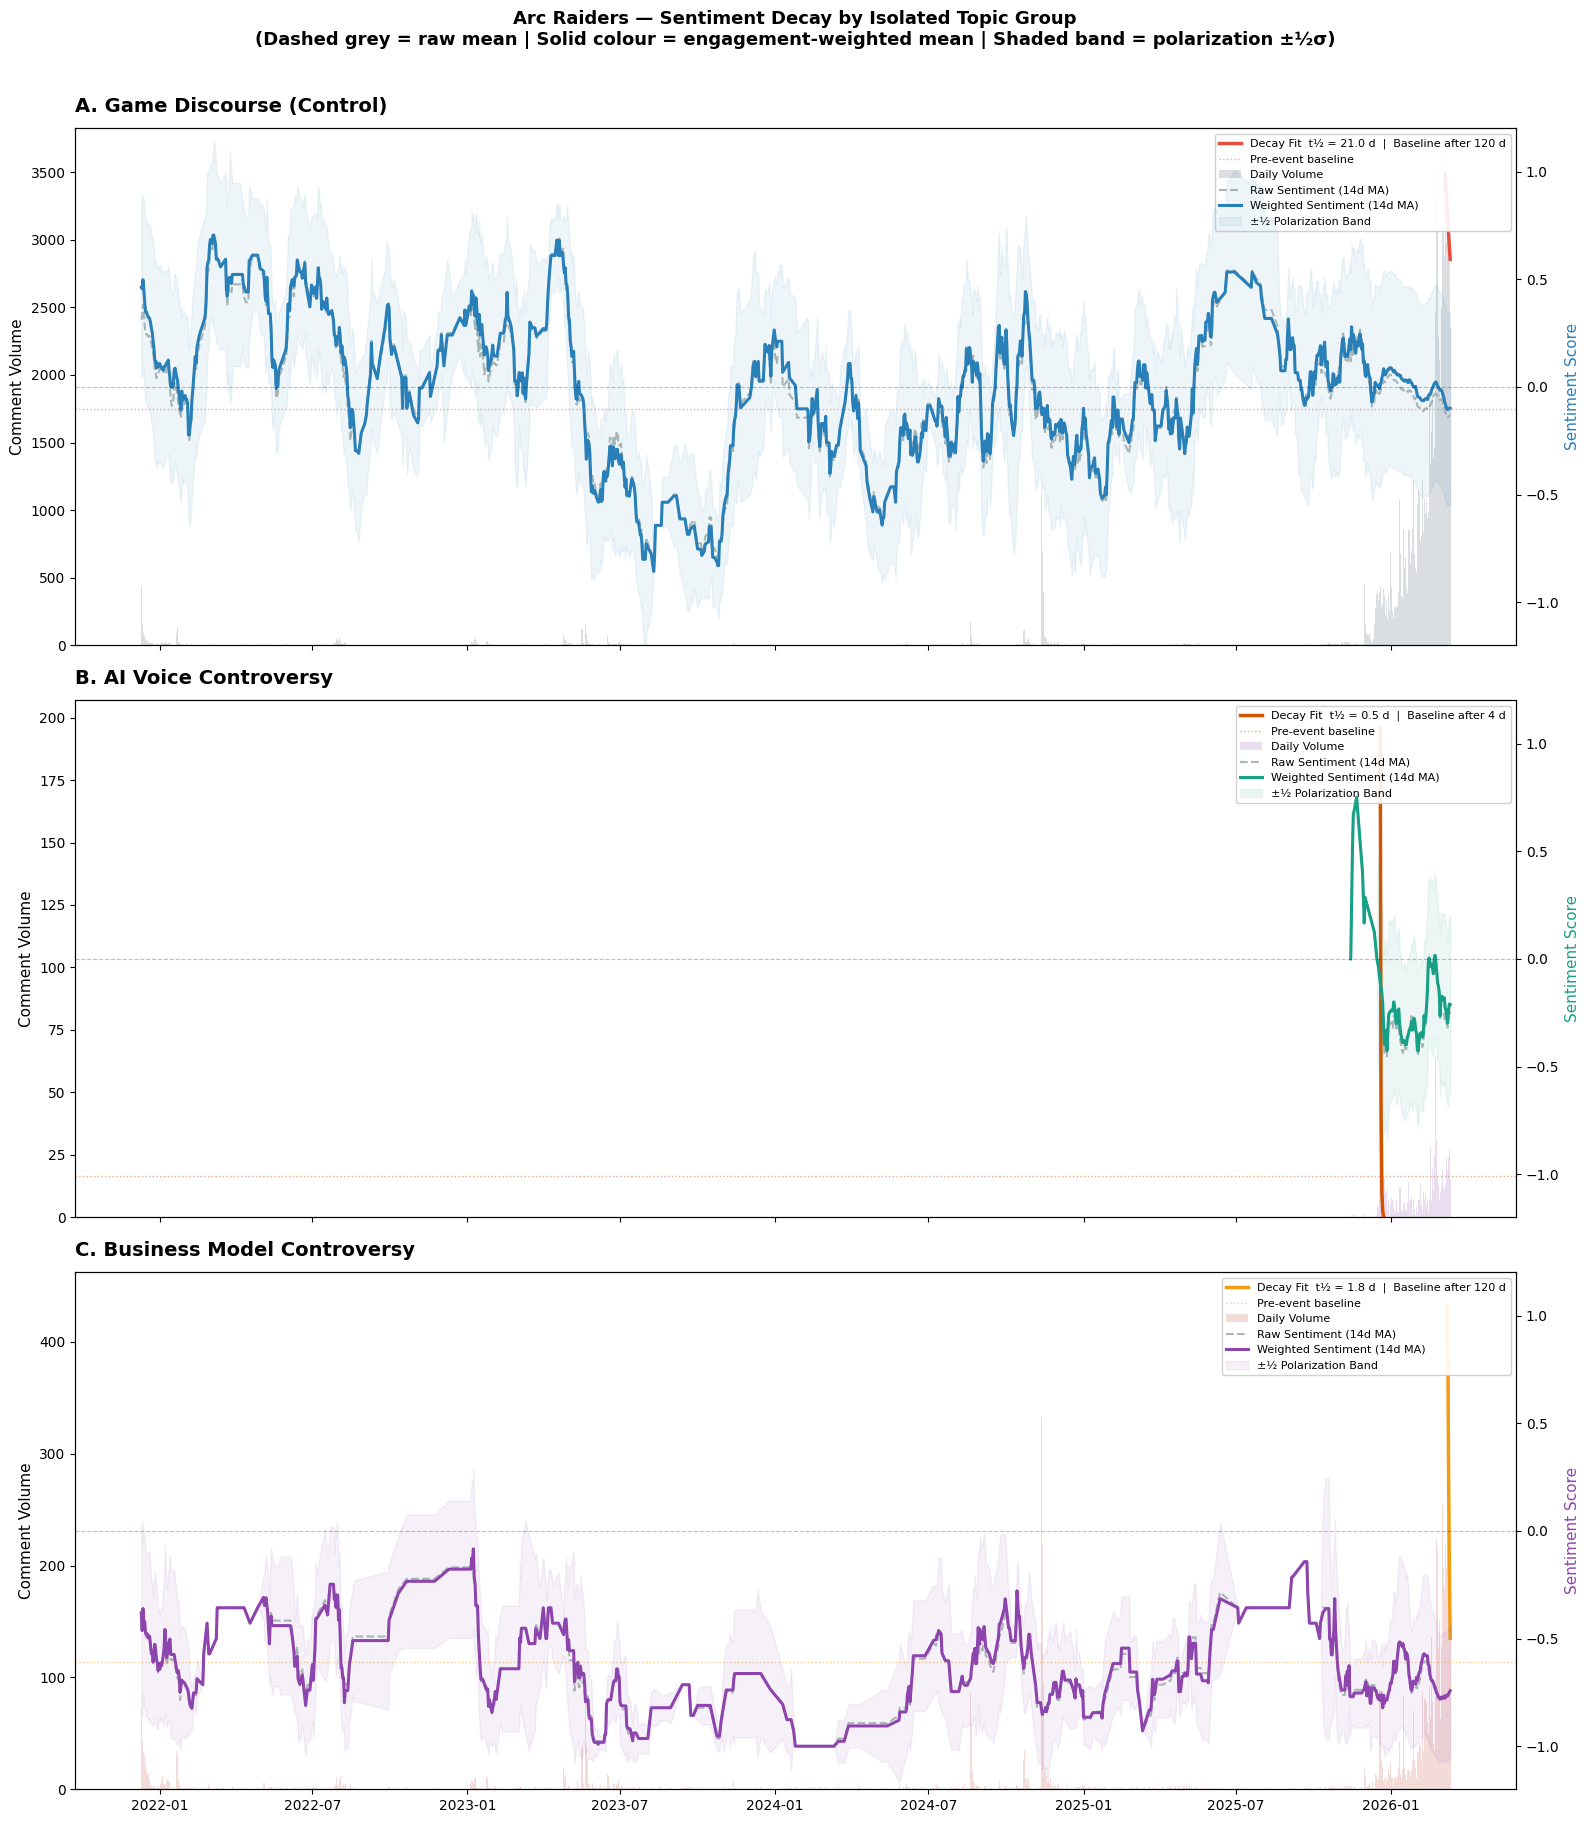

DECAY ANALYSIS RESULTS
Game Discourse (Control)         | Peak: 2026-03-06 | t½:   21.0 d | λ: 0.0330 | Fit window: 120 d (dynamic)
AI Voice Controversy             | Peak: 2025-12-19 | t½:    0.5 d | λ: 1.5173 | Fit window: 4 d (dynamic)
Business Model Controversy       | Peak: 2026-03-09 | t½:    1.8 d | λ: 0.3871 | Fit window: 120 d (dynamic)


In [8]:
groups = [
    {
        'daily':     daily_game,
        'results':   game_results,
        'label':     'Game Discourse (Control)',
        'bar_color': '#34495E',
        'fit_color': '#E74C3C',
        'raw_color': '#95a5a6',
        'wgt_color': '#2980B9',
    },
    {
        'daily':     daily_ai,
        'results':   ai_results,
        'label':     'AI Voice Controversy',
        'bar_color': '#8E44AD',
        'fit_color': '#D35400',
        'raw_color': '#95a5a6',
        'wgt_color': '#16A085',
    },
    {
        'daily':     daily_biz,
        'results':   biz_results,
        'label':     'Business Model Controversy',
        'bar_color': '#C0392B',
        'fit_color': '#F39C12',
        'raw_color': '#95a5a6',
        'wgt_color': '#8E44AD',
    },
]

fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)
WINDOW = 14   # rolling window for sentiment MA
CUTOFF_DATE = pd.to_datetime("2025-11-12") # For AI News alone

for i, (ax, g) in enumerate(zip(axes, groups)):
    daily   = g['daily'].copy()
    results = g['results']

    # FILTER ONLY FOR AI VOICE CONTROVERSY
    if g['label'] == "AI Voice Controversy":
        daily = daily[daily['comment_date'] >= CUTOFF_DATE]

    # Volume bars
    ax.bar(daily['comment_date'], daily['volume'],
           color=g['bar_color'], alpha=0.18, label='Daily Volume', width=1)

    # Decay fit curve
    if results:
        ax.plot(results['fit_dates'], results['fit_values'],
                color=g['fit_color'], linewidth=2.5, zorder=5,
                label=f"Decay Fit  t½ = {results['half_life']:.1f} d  |  "
                      f"Baseline after {results['fit_days']} d")
        # Baseline reference line
        ax.axhline(results['baseline_vol'], color=g['fit_color'],
                   linewidth=1, linestyle=':', alpha=0.5, label='Pre-event baseline')

    # --- AGREEMENT GAP: Raw Sentiment vs Weighted Sentiment ---
    ax_s = ax.twinx()

    raw_ma = daily['sentiment'].rolling(WINDOW, min_periods=1).mean()
    wgt_ma = daily['weighted_sentiment'].rolling(WINDOW, min_periods=1).mean()
    wgt_std = daily['sentiment_std'].rolling(WINDOW, min_periods=1).mean()

    ax_s.plot(daily['comment_date'], raw_ma,
              color=g['raw_color'], linewidth=1.5, linestyle='--',
              label=f'Raw Sentiment ({WINDOW}d MA)', alpha=0.8)
    ax_s.plot(daily['comment_date'], wgt_ma,
              color=g['wgt_color'], linewidth=2.2,
              label=f'Weighted Sentiment ({WINDOW}d MA)')
    # Polarization band: ±½ std around weighted MA (shaded)
    ax_s.fill_between(daily['comment_date'],
                      wgt_ma - 0.5 * wgt_std.fillna(0),
                      wgt_ma + 0.5 * wgt_std.fillna(0),
                      color=g['wgt_color'], alpha=0.08, label='±½ Polarization Band')
    ax_s.axhline(0, color='black', linestyle='--', alpha=0.25, linewidth=0.8)
    ax_s.set_ylim(-1.2, 1.2)

    # Formatting
    panel = chr(65 + i)   # A, B, C
    ax.set_title(f"{panel}. {g['label']}", loc='left',
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_ylabel("Comment Volume", fontsize=11)
    ax_s.set_ylabel("Sentiment Score", color=g['wgt_color'], fontsize=11)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_s.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8, framealpha=0.9)

plt.xlabel("Timeline", fontsize=13, fontweight='bold')
plt.suptitle("Arc Raiders — Sentiment Decay by Isolated Topic Group\n"
             "(Dashed grey = raw mean | Solid colour = engagement-weighted mean | "
             "Shaded band = polarization ±½σ)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_ArcRaiders_Decay_ThreeGroups.png'),
            dpi=400, bbox_inches='tight')
plt.show()

print(f"{'='*60}")
print("DECAY ANALYSIS RESULTS")
print(f"{'='*60}")
for g in groups:
    r = g['results']
    if r:
        print(f"{g['label']:<32} | Peak: {r['peak_date'].date()} | "
              f"t½: {r['half_life']:>6.1f} d | "
              f"λ: {r['decay_constant']:.4f} | "
              f"Fit window: {r['fit_days']} d (dynamic)")
print(f"{'='*60}")

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def get_plotly_daily(df_subset, window=14):
    daily = df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume                 = ('comment_id',           'count'),
        raw_sentiment          = ('sentiment_score',      'mean'),
        sum_weighted_sentiment = ('weighted_sentiment',   'sum'),
        sum_weights            = ('weight_factor',        'sum'),
    ).reset_index()
    daily['weighted_sentiment'] = daily['sum_weighted_sentiment'] / daily['sum_weights']
    daily['raw_ma']             = daily['raw_sentiment'].rolling(window, min_periods=1).mean()
    daily['weighted_ma']        = daily['weighted_sentiment'].rolling(window, min_periods=1).mean()
    return daily

plotly_game = get_plotly_daily(df_game)
plotly_ai   = get_plotly_daily(df_ai)
plotly_biz  = get_plotly_daily(df_biz)

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=(
        "A. Game Discourse — Control Baseline",
        "B. AI Voice Controversy",
        "C. Business Model Controversy",
    ),
    specs=[[{"secondary_y": True}]] * 3,
)

subplot_config = [
    (plotly_game, 'rgba(44,62,80,0.85)',    '#95a5a6', '#2980B9',  'Game Volume',   1),
    (plotly_ai,   'rgba(142,68,173,0.55)',  '#95a5a6', '#16A085',  'AI Volume',     2),
    (plotly_biz,  'rgba(192,57,43,0.55)',   '#95a5a6', '#8E44AD',  'Biz Volume',    3),
]

for daily, bar_col, raw_col, wgt_col, vol_name, row in subplot_config:
    # Volume bars
    fig.add_trace(
        go.Bar(x=daily['comment_date'], y=daily['volume'],
               name=vol_name, marker_color=bar_col, showlegend=(row == 1)),
        row=row, col=1, secondary_y=False,
    )
    # Raw (unweighted) sentiment line — grey dashed
    fig.add_trace(
        go.Scatter(
            x=daily['comment_date'], y=daily['raw_ma'],
            name='Raw Sentiment (7d MA)', line=dict(color=raw_col, width=1.8, dash='dot'),
            showlegend=(row == 1),
        ),
        row=row, col=1, secondary_y=True,
    )
    # Engagement-weighted sentiment line — coloured solid
    fig.add_trace(
        go.Scatter(
            x=daily['comment_date'], y=daily['weighted_ma'],
            name='Weighted Sentiment (7d MA)', line=dict(color=wgt_col, width=2.5),
            showlegend=(row == 1),
        ),
        row=row, col=1, secondary_y=True,
    )

fig.update_layout(
    height=1000,
    title_text=(
        "Arc Raiders — Engagement-Weighted vs Raw Sentiment<br>"
        "<sup>Gap between dashed (raw) and solid (weighted) lines = "
        "high-engagement comments pulling sentiment lower</sup>"
    ),
    showlegend=True,
    xaxis3_title="Timeline  (Click & drag to zoom)",
    xaxis_rangeselector=dict(
        buttons=[
            dict(count=1,  label="1m",  step="month", stepmode="backward"),
            dict(count=6,  label="6m",  step="month", stepmode="backward"),
            dict(step="all"),
        ]
    ),
)

fig.update_yaxes(title_text="Volume",    secondary_y=False)
fig.update_yaxes(title_text="Sentiment", range=[-1.2, 1.2], secondary_y=True)
fig.show()

---

## Section 4.1 — Dataset Statistics

In [10]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total labeled comments:  {len(df):,}")
print(f"Date range:              {df['comment_date'].min().date()} → {df['comment_date'].max().date()}")
print(f"Unique videos:           {df['video_id'].nunique():,}")
print(f"Unique commenters:       {df['author_hash'].nunique():,}")

print("\n--- Sentiment Distribution ---")
sent_counts = df['sentiment'].value_counts()
sent_pct    = df['sentiment'].value_counts(normalize=True) * 100
sent_table  = pd.DataFrame({'Count': sent_counts, 'Pct (%)': sent_pct.round(2)})
print(sent_table.to_string())

print("\n--- Category Distribution ---")
cat_counts = df['category'].value_counts()
cat_pct    = df['category'].value_counts(normalize=True) * 100
cat_table  = pd.DataFrame({'Count': cat_counts, 'Pct (%)': cat_pct.round(2)})
print(cat_table.to_string())

print("\n--- Confidence Distribution ---")
print(df['confidence'].describe().round(3).to_string())
low_conf_n = (df['confidence'] < 0.70).sum()
print(f"\nLLM labels with confidence < 0.70: {low_conf_n:,} ({100*low_conf_n/len(df):.1f}%)")

DATASET OVERVIEW
Total labeled comments:  182,552
Date range:              2021-12-10 → 2026-03-13
Unique videos:           1,179
Unique commenters:       104,688

--- Sentiment Distribution ---
            Count  Pct (%)
sentiment                 
Neg         58374    47.72
Pos         42026    34.35
Neu         20017    16.36
Ambivalent   1914     1.56

--- Category Distribution ---
                         Count  Pct (%)
category                               
Game_Related            112470    91.94
Business_Model_Related    8513     6.96
AI_Voice_Related          1348     1.10

--- Confidence Distribution ---
count    122331.000
mean          0.837
std           0.060
min           0.400
25%           0.800
50%           0.800
75%           0.900
max           0.950

LLM labels with confidence < 0.70: 2,502 (1.4%)


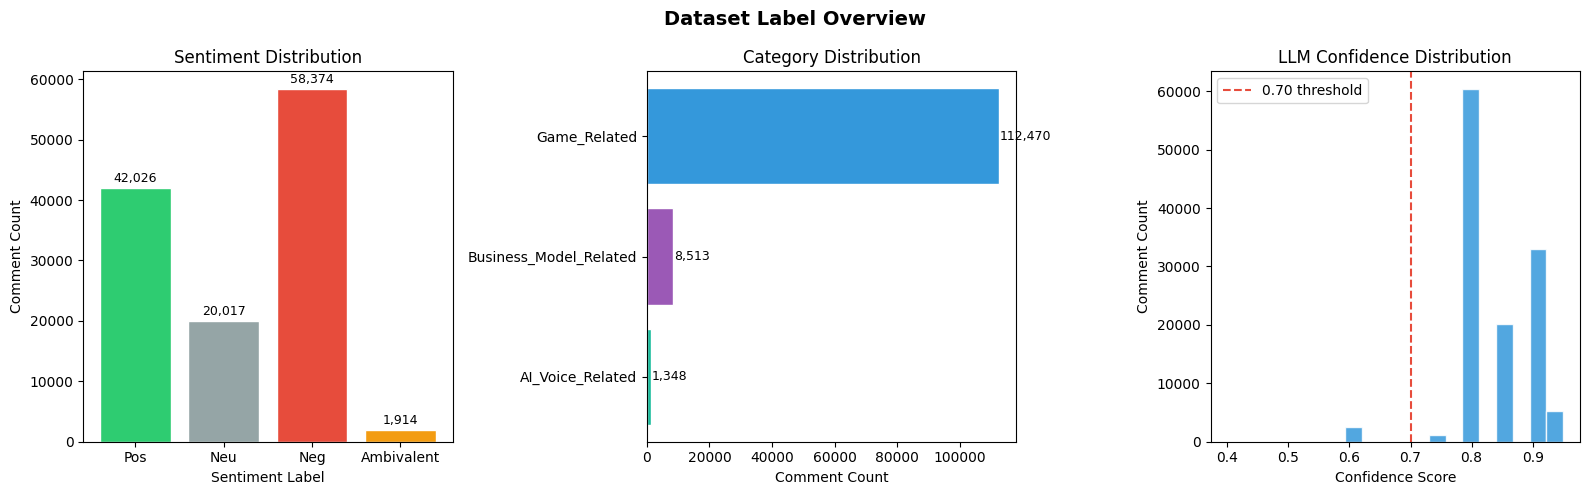

Saved → figures/06_dataset_label_overview.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Label Overview", fontsize=14, fontweight='bold')

SENT_ORDER = ['Pos', 'Neu', 'Neg', 'Ambivalent']
SENT_COLORS = {'Pos': '#2ecc71', 'Neu': '#95a5a6', 'Neg': '#e74c3c', 'Ambivalent': '#f39c12'}
CAT_COLORS  = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22']

# --- Sentiment bar ---
ax = axes[0]
order = [s for s in SENT_ORDER if s in sent_counts.index]
colors = [SENT_COLORS[s] for s in order]
ax.bar(order, sent_counts[order], color=colors, edgecolor='white')
for bar, val in zip(ax.patches, sent_counts[order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Sentiment Distribution')
ax.set_ylabel('Comment Count')
ax.set_xlabel('Sentiment Label')

# --- Category bar ---
ax = axes[1]
cats = cat_counts.index.tolist()
ax.barh(cats, cat_counts[cats], color=CAT_COLORS, edgecolor='white')
for bar, val in zip(ax.patches, cat_counts[cats]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Category Distribution')
ax.set_xlabel('Comment Count')
ax.invert_yaxis()

# --- LLM Confidence histogram ---
ax = axes[2]
ax.hist(df['confidence'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.70, color='#e74c3c', linewidth=1.5, linestyle='--', label='0.70 threshold')
ax.set_title('LLM Confidence Distribution')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Comment Count')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_dataset_label_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/06_dataset_label_overview.png")

---
## Section 4.2 — Event Detection

In [12]:
# Spike days already flagged via z-score in your wrangling notebook
spike_days = df[df['is_spike'] == True].groupby(
    df['comment_date'].dt.date
).agg(
    volume=('comment_id', 'count'),
    z_score=('z_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})

spike_days = spike_days.sort_values('date').reset_index(drop=True)

# Cluster spikes that are within 3 days of each other into one event
CLUSTER_GAP_DAYS = 3
spike_days['date'] = pd.to_datetime(spike_days['date'])

clusters = []
current_cluster = [spike_days.iloc[0]]
for i in range(1, len(spike_days)):
    row = spike_days.iloc[i]
    if (row['date'] - current_cluster[-1]['date']).days <= CLUSTER_GAP_DAYS:
        current_cluster.append(row)
    else:
        clusters.append(current_cluster)
        current_cluster = [row]
clusters.append(current_cluster)

# Pick the peak day within each cluster as the event anchor
events_detected = []
for cluster in clusters:
    cluster_df = pd.DataFrame(cluster)
    peak_row = cluster_df.loc[cluster_df['volume'].idxmax()]
    events_detected.append({
        'event_date': peak_row['date'].date(),
        'peak_volume': int(peak_row['volume']),
        'mean_z_score': round(cluster_df['z_score'].mean(), 2),
        'cluster_days': len(cluster)
    })

events_df = pd.DataFrame(events_detected).sort_values('peak_volume', ascending=False)

print(f"Total spike days detected:   {len(spike_days)}")
print(f"Clustered into events:       {len(events_df)}")
print("\nTop events by volume (fill in 'event_label' column manually below):")
print(events_df.to_string(index=False))

Total spike days detected:   57
Clustered into events:       33

Top events by volume (fill in 'event_label' column manually below):
event_date  peak_volume  mean_z_score  cluster_days
2026-02-24         5115          3.16             3
2026-02-15         3051          2.80             1
2026-01-16         1778          3.86             2
2024-11-12         1736          5.20             1
2026-01-11         1469          2.97             1
2025-11-30          677          4.08             3
2024-08-20          340          5.26             1
2022-01-22          272          3.93             2
2023-05-21          253          3.12             1
2024-10-23          228          4.51             2
2023-05-16          200          3.79             2
2025-12-05          141          3.69             1
2023-04-25          117          5.21             1
2023-01-10           94          4.24             5
2022-07-30           68          3.99             4
2024-07-10           63          5.

In [13]:
# Known events — used directly as anchors regardless of volume spike
KNOWN_EVENTS = {
    '2021-12-09': 'Game Announcement',
    '2023-05-01': 'PvPvE Design Pivot',
    '2025-06-06': 'Business Model Change',
    '2025-10-30': 'Official Game Launch',
    '2025-11-12': 'AI Voice Acting News',
    '2026-01-23': 'Roadmap 2026',
    '2026-03-15': 'AI Voice Replacement',
}

# Ensure datetime once
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

confirmed_events = pd.DataFrame([
    {'event_date': pd.to_datetime(date), 'event_label': label}
    for date, label in KNOWN_EVENTS.items()
])

def get_peak_after(d):
    # Filter to only future (or same-day) events
    df = events_df[events_df['event_date'] >= d]

    if df.empty:
        return None

    # Find closest future date
    time_deltas = df['event_date'] - d
    idx = time_deltas.idxmin()

    # Enforce 30-day window
    if time_deltas.loc[idx].days <= 30:
        return df.loc[idx, 'peak_volume']

    return None

# Apply function
confirmed_events['peak_volume'] = confirmed_events['event_date'].apply(get_peak_after)

print(confirmed_events[['event_date', 'event_label', 'peak_volume']].to_string(index=False))

event_date           event_label  peak_volume
2021-12-09     Game Announcement          NaN
2023-05-01    PvPvE Design Pivot        200.0
2025-06-06 Business Model Change          NaN
2025-10-30  Official Game Launch          NaN
2025-11-12  AI Voice Acting News        677.0
2026-01-23          Roadmap 2026       3051.0
2026-03-15  AI Voice Replacement          NaN


In [14]:
# Map specific event labels to broader categories for the taxonomy chart
EVENT_CATEGORIES = {
    'Game Announcement':     'Game_Related',
    'PvPvE Design Pivot':    'Business_Model_Related',
    'Business Model Change': 'Business_Model_Related',
    'Official Game Launch':  'Game_Related',
    'AI Voice Acting News':  'AI_Voice_Related',
    'Roadmap 2026':          'Game_Related',
    'AI Voice Replacement':  'AI_Voice_Related',
}

confirmed_events['category'] = confirmed_events['event_label'].map(EVENT_CATEGORIES)

# Chart by category
label_counts = confirmed_events['category'].value_counts()

TAXONOMY_COLORS = {
    'Game_Related':            '#3498db',
    'Business_Model_Related':  '#e67e22',
    'AI_Voice_Related':        '#9b59b6',
}

---
## Section 4.3 — Temporal Sentiment Windows

In [15]:
# =============================================================================
# Pre-event: 7 days before | Event: ±2 days | Post-event: 7 days after
# LLM labels used as ground truth throughout
# =============================================================================
PRE_DAYS     = 7
POST_DAYS    = 7
EVENT_WINDOW = 2  # ±2 days around event anchor

def classify_window(comment_date, event_date):
    delta = (comment_date - event_date).days
    if -PRE_DAYS <= delta < -EVENT_WINDOW:
        return 'Pre-Event'
    elif -EVENT_WINDOW <= delta <= EVENT_WINDOW:
        return 'Event'
    elif EVENT_WINDOW < delta <= POST_DAYS:
        return 'Post-Event'
    return None

window_records = []
for _, event_row in confirmed_events.iterrows():
    edate    = event_row['event_date']
    elabel   = event_row['event_label']
    ecategory = event_row['category']

    window_start = edate - pd.Timedelta(days=PRE_DAYS)
    window_end   = edate + pd.Timedelta(days=POST_DAYS)

    mask = (df['comment_date'] >= window_start) & (df['comment_date'] <= window_end)
    subset = df[mask].copy()
    subset['window']         = subset['comment_date'].apply(lambda d: classify_window(d, edate))
    subset = subset[subset['window'].notna()]
    subset['event_label']    = elabel
    subset['event_date']     = edate
    subset['event_category'] = ecategory
    window_records.append(subset)

if window_records:
    windows_df = pd.concat(window_records, ignore_index=True)
    print(f"Total windowed comment rows: {len(windows_df):,}")
    print(windows_df.groupby(['event_category', 'event_label', 'window'])['sentiment_score']
          .agg(['count', 'mean']).round(3))
else:
    print("⚠️  No confirmed events yet.")
    windows_df = pd.DataFrame()

Total windowed comment rows: 44,429
                                                         count   mean
event_category         event_label           window                  
AI_Voice_Related       AI Voice Acting News  Event         103  0.068
                                             Post-Event     43  0.233
                                             Pre-Event      95 -0.021
                       AI Voice Replacement  Event           0    NaN
                                             Pre-Event   16818 -0.181
Business_Model_Related Business Model Change Event           8  0.500
                                             Post-Event      1  1.000
                                             Pre-Event      23  0.348
                       PvPvE Design Pivot    Event          89 -0.236
                                             Post-Event     17  0.000
                                             Pre-Event     243 -0.037
Game_Related           Game Announcement     Event    

In [16]:
# Aggregate: mean sentiment score and sentiment ratio per window per event

if not windows_df.empty:
    WINDOW_ORDER = ['Pre-Event', 'Event', 'Post-Event']

    window_agg = windows_df.groupby(['event_label', 'window']).agg(
        comment_count   = ('comment_id',      'count'),
        mean_sentiment  = ('sentiment_score', 'mean'),
        polarization    = ('sentiment_score', 'std'),   # ← NEW: high = community split
        pct_pos         = ('sentiment', lambda x: (x == 'Pos').mean() * 100),
        pct_neg         = ('sentiment', lambda x: (x == 'Neg').mean() * 100),
        pct_neu         = ('sentiment', lambda x: (x == 'Neu').mean() * 100),
    ).reset_index()

    window_agg['window'] = pd.Categorical(
        window_agg['window'], categories=WINDOW_ORDER, ordered=True
    )
    window_agg = window_agg.sort_values(['event_label', 'window'])

    print("Sentiment by Event × Window (with Polarization Index):")
    print(window_agg[['event_label', 'window', 'comment_count',
                       'mean_sentiment', 'polarization',
                       'pct_pos', 'pct_neg', 'pct_neu']].to_string(index=False))

    # --- Flag polarized events (high std + near-zero mean = community split) ---
    event_window = window_agg[window_agg['window'] == 'Event'].copy()
    event_window['is_polarized'] = (
        (event_window['polarization'] > 0.6) &
        (event_window['mean_sentiment'].abs() < 0.2)
    )
    polarized = event_window[event_window['is_polarized']]['event_label'].tolist()
    if polarized:
        print(f"\n⚠️  Polarized Events (split community, near-zero mean + high σ): {polarized}")
    else:
        print("\nNo strongly polarized events detected (no community civil war pattern).")

Sentiment by Event × Window (with Polarization Index):
          event_label     window  comment_count  mean_sentiment  polarization   pct_pos   pct_neg   pct_neu
 AI Voice Acting News  Pre-Event            118       -0.021053      0.898923 31.355932 33.050847 11.016949
 AI Voice Acting News      Event            122        0.067961      0.866163 34.426230 28.688525 16.393443
 AI Voice Acting News Post-Event             55        0.232558      0.921624 43.636364 25.454545  9.090909
 AI Voice Replacement  Pre-Event          24803       -0.180699      0.891306 21.912672 34.165222 10.938193
 AI Voice Replacement      Event              2             NaN           NaN  0.000000  0.000000  0.000000
Business Model Change  Pre-Event             32        0.347826      0.831685 40.625000 15.625000  9.375000
Business Model Change      Event             11        0.500000      0.925820 54.545455 18.181818  0.000000
Business Model Change Post-Event              2        1.000000           NaN 50.

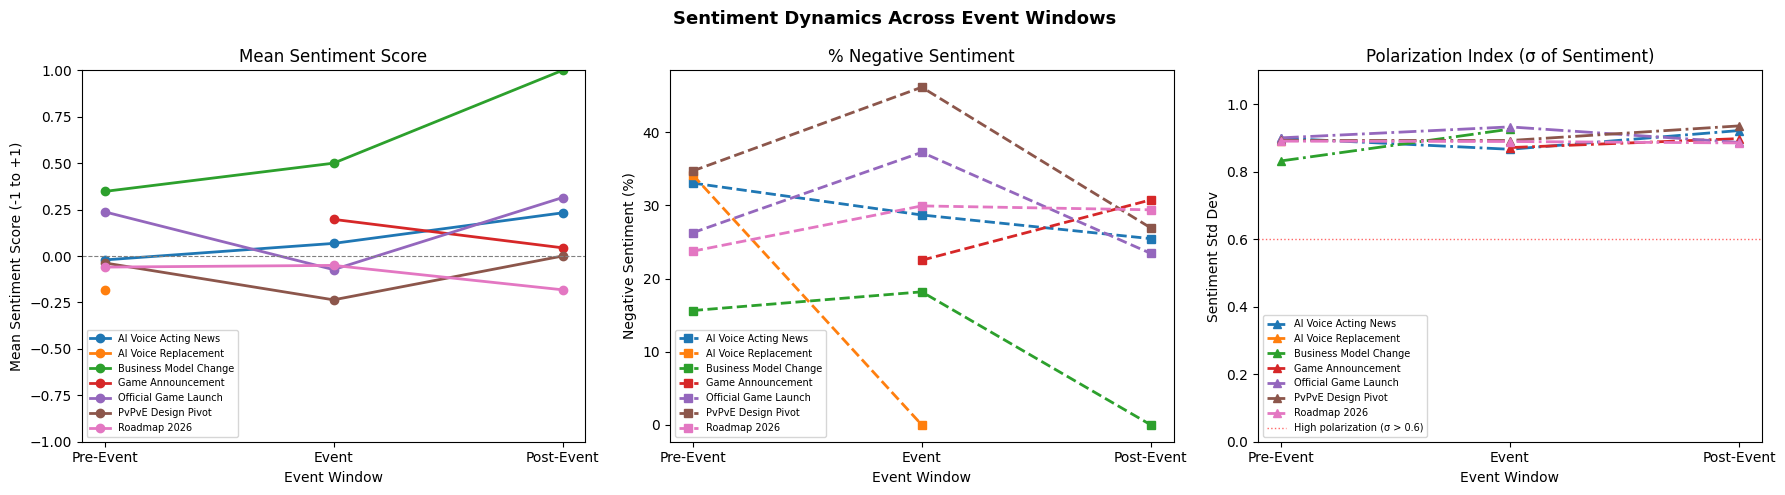

Saved → figures/07_temporal_sentiment_windows.png


In [17]:
# Publication-ready figure: mean sentiment across windows, one line per event type

if not windows_df.empty:
    event_labels = window_agg['event_label'].unique()
    palette = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Sentiment Dynamics Across Event Windows', fontsize=13, fontweight='bold')

    # Panel 1: Mean sentiment score
    ax = axes[0]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['mean_sentiment'],
                marker='o', label=label, color=palette[i], linewidth=2)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title('Mean Sentiment Score')
    ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=7)
    ax.set_ylim(-1, 1)

    # Panel 2: % Negative sentiment
    ax = axes[1]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['pct_neg'],
                marker='s', label=label, color=palette[i], linewidth=2, linestyle='--')
    ax.set_title('% Negative Sentiment')
    ax.set_ylabel('Negative Sentiment (%)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=7)

    # Panel 3: Polarization Index (sentiment std) ← NEW
    ax = axes[2]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['polarization'],
                marker='^', label=label, color=palette[i], linewidth=2, linestyle='-.')
    ax.axhline(0.6, color='red', linewidth=1, linestyle=':', alpha=0.6, label='High polarization (σ > 0.6)')
    ax.set_title('Polarization Index (σ of Sentiment)')
    ax.set_ylabel('Sentiment Std Dev')
    ax.set_xlabel('Event Window')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '07_temporal_sentiment_windows.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → figures/07_temporal_sentiment_windows.png")

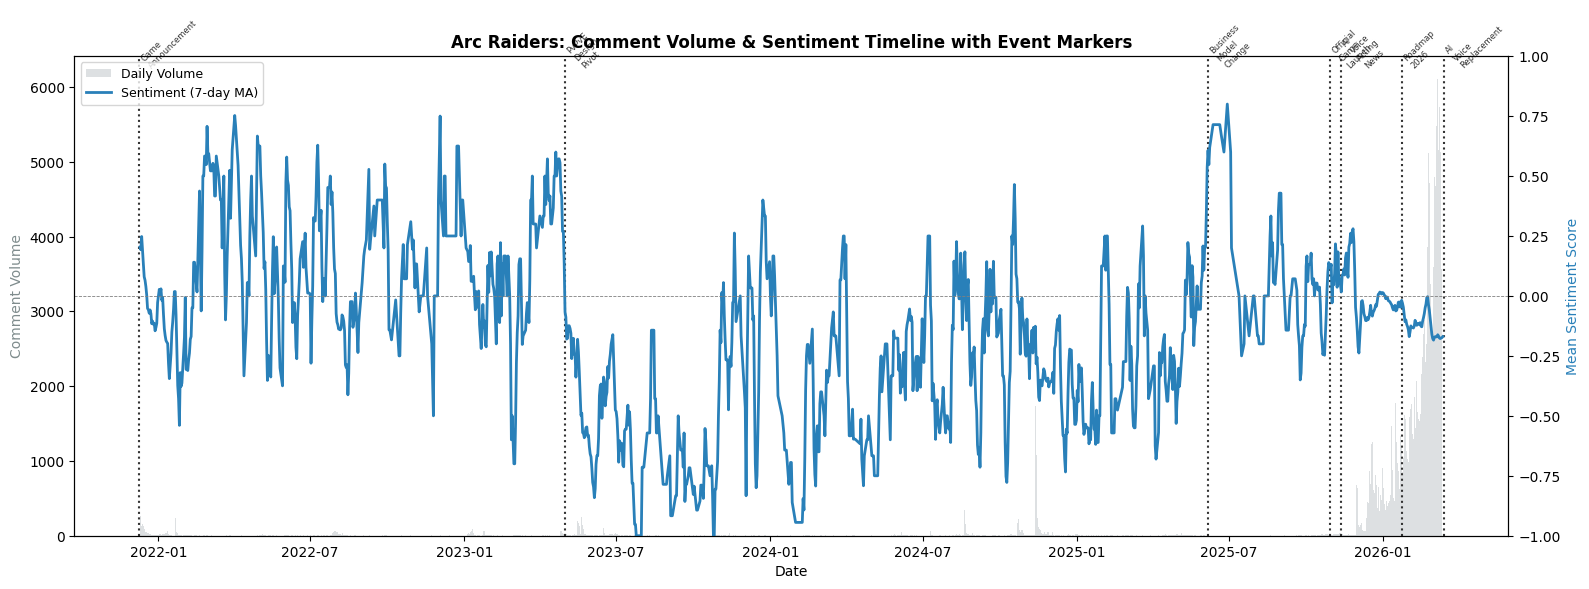

Saved → figures/08_full_timeline_with_events.png


In [18]:
# Full timeline figure: daily sentiment + event markers

daily_all = df.groupby(df['comment_date'].dt.date).agg(
    volume=('comment_id', 'count'),
    mean_sentiment=('sentiment_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})
daily_all['date'] = pd.to_datetime(daily_all['date'])
daily_all['sentiment_ma7'] = daily_all['mean_sentiment'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(daily_all['date'], daily_all['volume'],
        color='#bdc3c7', alpha=0.5, label='Daily Volume', width=1)
ax2.plot(daily_all['date'], daily_all['sentiment_ma7'],
         color='#2980b9', linewidth=2, label='Sentiment (7-day MA)')
ax2.axhline(0, color='grey', linewidth=0.6, linestyle='--')

# Event markers
if not confirmed_events.empty:
    for _, ev in confirmed_events.iterrows():
        color = TAXONOMY_COLORS.get(ev['event_label'], '#333')
        ax1.axvline(ev['event_date'], color=color, linewidth=1.5, linestyle=':')
        ax1.text(ev['event_date'], daily_all['volume'].max() * 1.02,
                 ev['event_label'].replace(' ', '\n'),
                 fontsize=6, color=color, rotation=45, ha='left', va='bottom')

ax1.set_xlabel('Date')
ax1.set_ylabel('Comment Volume', color='#7f8c8d')
ax2.set_ylabel('Mean Sentiment Score', color='#2980b9')
ax2.set_ylim(-1, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Arc Raiders: Comment Volume & Sentiment Timeline with Event Markers',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_full_timeline_with_events.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/08_full_timeline_with_events.png")

---
## Section 4.4 — Per-Category Sentiment Breakdown

In [19]:
CAT_ORDER  = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related']
SENT_ORDER_FULL = ['Pos', 'Neu', 'Neg', 'Ambivalent']

cat_sent = df.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
# Ensure all sentiment columns present
for col in SENT_ORDER_FULL:
    if col not in cat_sent.columns:
        cat_sent[col] = 0
cat_sent = cat_sent[SENT_ORDER_FULL].loc[CAT_ORDER]

cat_sent_pct = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100

print("Sentiment % by Category:")
print(cat_sent_pct.round(2).to_string())

print("\nMean Sentiment Score by Category:")
print(df.groupby('category')['sentiment_score'].agg(['mean', 'std', 'count']).round(3).loc[CAT_ORDER].to_string())

Sentiment % by Category:
sentiment                 Pos    Neu    Neg  Ambivalent
category                                               
Game_Related            36.28  17.06  45.05        1.60
AI_Voice_Related        21.51  22.55  53.49        2.45
Business_Model_Related  10.89   6.14  82.02        0.95

Mean Sentiment Score by Category:
                         mean    std   count
category                                    
Game_Related           -0.088  0.898  112470
AI_Voice_Related       -0.320  0.805    1348
Business_Model_Related -0.711  0.651    8513


/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_43695/2570750948.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)


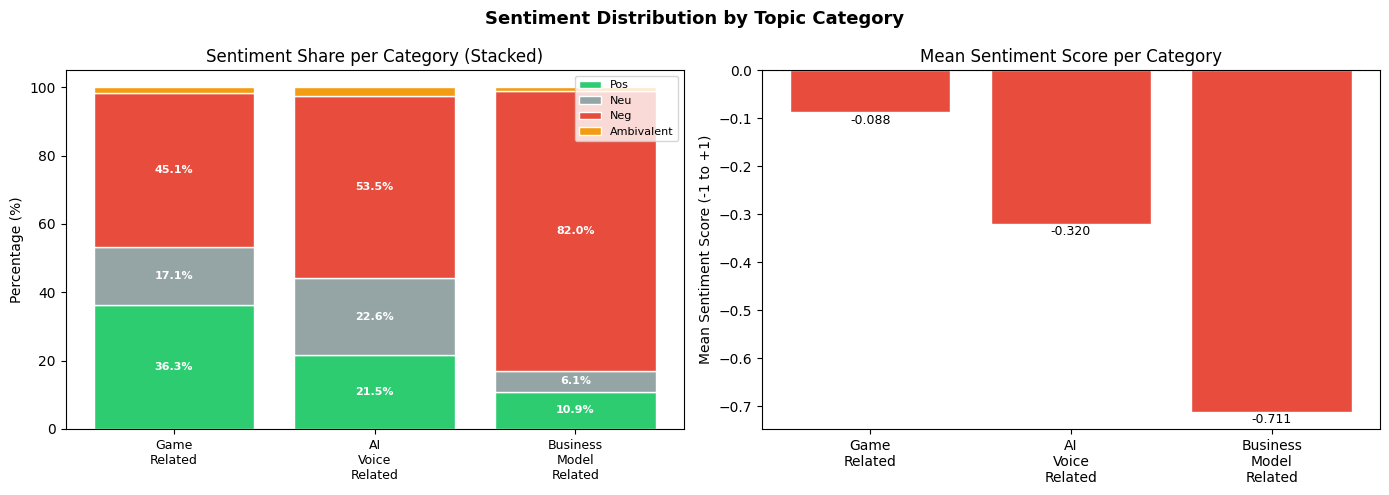

Saved → figures/09_category_sentiment_breakdown.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Distribution by Topic Category', fontsize=13, fontweight='bold')

# Left: stacked bar (% sentiment per category)
ax = axes[0]
bottom = np.zeros(len(CAT_ORDER))
bar_colors = [SENT_COLORS[s] for s in SENT_ORDER_FULL]
for sent, color in zip(SENT_ORDER_FULL, bar_colors):
    vals = cat_sent_pct[sent].values
    bars = ax.bar(CAT_ORDER, vals, bottom=bottom, label=sent, color=color, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 4:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Sentiment Share per Category (Stacked)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)
ax.legend(loc='upper right', fontsize=8)

# Right: mean sentiment score per category
ax = axes[1]
mean_scores = df.groupby('category')['sentiment_score'].mean().loc[CAT_ORDER]
bar_clrs = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mean_scores.values]
ax.bar([c.replace('_', '\n') for c in CAT_ORDER], mean_scores.values,
       color=bar_clrs, edgecolor='white')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Mean Sentiment Score per Category')
ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
for bar, val in zip(ax.patches, mean_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.01 if val >= 0 else -0.03),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_category_sentiment_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/09_category_sentiment_breakdown.png")

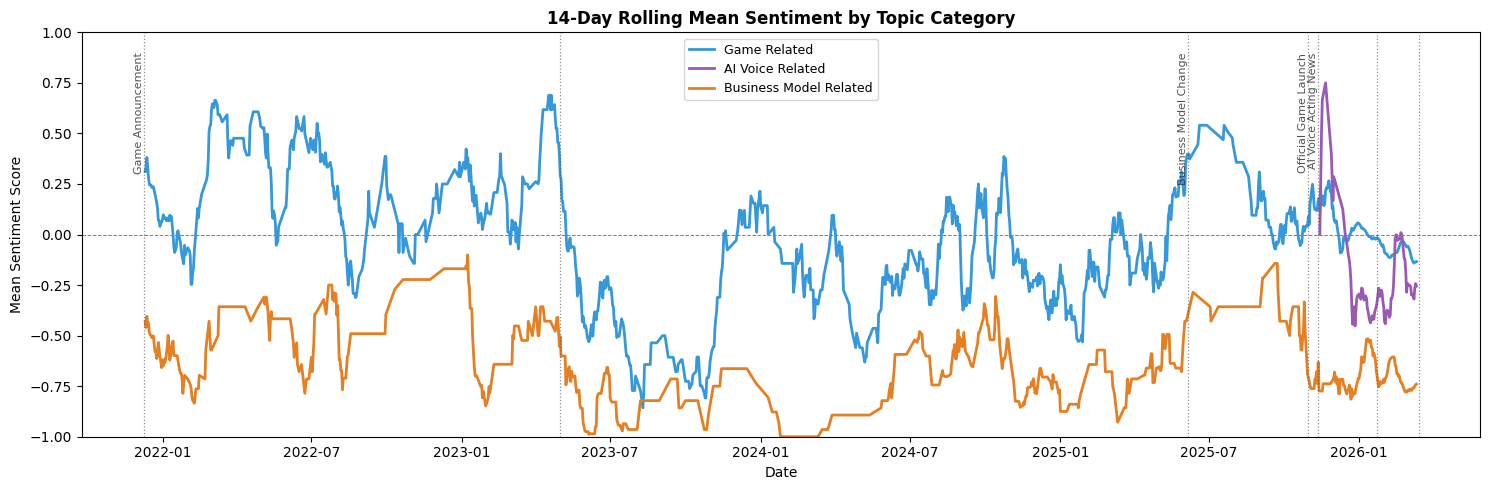

Saved → figures/10_category_sentiment_timeseries.png


In [21]:
# Category sentiment over time — shows AI/Business trending negative
fig, ax = plt.subplots(figsize=(15, 5))

category_colors = {
    'Game_Related':            '#3498db',
    'AI_Voice_Related':        '#9b59b6',
    'Business_Model_Related':  '#e67e22'
}
CUTOFF_DATE = pd.to_datetime("2025-11-12")

for cat in CAT_ORDER:
    subset = df[df['category'] == cat].copy()

    # --- FILTER ONLY AI CATEGORY ---
    if cat == 'AI_Voice_Related':
        subset = subset[subset['comment_date'] >= CUTOFF_DATE]

    daily_cat = subset.groupby(subset['comment_date'].dt.date)['sentiment_score'].mean().reset_index()
    daily_cat.columns = ['date', 'sentiment_ma']
    daily_cat['date'] = pd.to_datetime(daily_cat['date'])
    daily_cat = daily_cat.sort_values('date')
    daily_cat['sentiment_ma'] = daily_cat['sentiment_ma'].rolling(14, min_periods=1).mean()
    ax.plot(daily_cat['date'], daily_cat['sentiment_ma'],
            label=cat.replace('_', ' '),
            color=category_colors[cat],
            linewidth=2)

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')

# --- EVENT LINES ---
for date_str, label in KNOWN_EVENTS.items():
    date = pd.to_datetime(date_str)

    ax.axvline(date,
               color='#444',
               linewidth=0.9,
               linestyle=':',
               alpha=0.6)

    # Only annotate key events to avoid clutter
    if label in [
        'Game Announcement',
        'Business Model Change',
        'Official Game Launch',
        'AI Voice Acting News'
    ]:
        ax.text(date,
                0.95,  # near top of plot
                label,
                rotation=90,
                verticalalignment='top',
                horizontalalignment='right',
                fontsize=8,
                color='#333',
                alpha=0.85,
                transform=ax.get_xaxis_transform())

ax.set_title('14-Day Rolling Mean Sentiment by Topic Category', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sentiment Score')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_category_sentiment_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/10_category_sentiment_timeseries.png")

---
## Section 4.7 — Confidence Analysis

In [22]:
# =============================================================================
# 4.7 CONFIDENCE ANALYSIS
# =============================================================================

# LLM confidence distribution
print("LLM Confidence Summary:")
print(df['confidence'].describe().round(3).to_string())

thresholds = [0.60, 0.70, 0.80, 0.90]
print("\nLLM label retention by confidence threshold:")
print(f"  {'Threshold':<12} {'Retained':>10} {'Pct %':>8}")
for t in thresholds:
    n = (df['confidence'] >= t).sum()
    print(f"  ≥ {t:<10} {n:>10,} {100*n/len(df):>7.1f}%")

LLM Confidence Summary:
count    122331.000
mean          0.837
std           0.060
min           0.400
25%           0.800
50%           0.800
75%           0.900
max           0.950

LLM label retention by confidence threshold:
  Threshold      Retained    Pct %
  ≥ 0.6           122,302    67.0%
  ≥ 0.7           119,829    65.6%
  ≥ 0.8           118,755    65.1%
  ≥ 0.9            38,311    21.0%


---
## Final Summary Report


  DEVELOPER INTELLIGENCE TAXONOMY
                     Group  N Comments  Peak Date  Half-Life (days)  Decay λ Fit Window (dynamic)         Classification
  Game Discourse (Control)      112470 2026-03-06              21.0   0.0330                120 d ⚠️  Fundamental Damage
      AI Voice Controversy        1278 2025-12-19               0.5   1.5173                  4 d          🔥 Wait it Out
Business Model Controversy        8513 2026-03-09               1.8   0.3871                120 d          🔥 Wait it Out

Interpretation:
  🔥 Wait it Out       → High volume, short half-life. Community anger is
                         transient. PR management and no response can suffice.
  ⚠️  Fundamental Damage → Moderate/high volume, long half-life. Sentiment
                         shift is structural. Product or policy change required;
                         PR alone cannot repair the baseline.


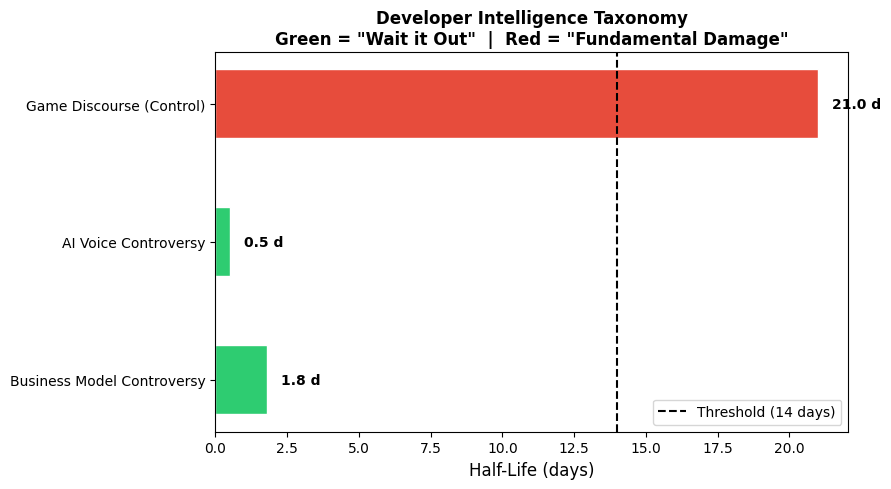

Saved → figures/11_Developer_Intelligence_Taxonomy.png


In [23]:
# =============================================================================
# DEVELOPER INTELLIGENCE TAXONOMY
# Classifies each controversy by its decay profile into actionable categories
# =============================================================================

def classify_event(half_life, hl_threshold=14):
    """
    Short half-life (≤ threshold): 'Wait it Out' — burns hot, fades fast.
    Long half-life (> threshold) : 'Fundamental Damage' — structural, must be addressed.
    """
    if half_life is None:
        return 'Unclassified'
    return '🔥 Wait it Out' if half_life <= hl_threshold else '⚠️  Fundamental Damage'

group_defs = [
    ('Game Discourse (Control)',        game_results, df_game),
    ('AI Voice Controversy',            ai_results,   df_ai),
    ('Business Model Controversy',      biz_results,  df_biz),
]

rows = []
for label, results, df_subset in group_defs:
    hl  = results['half_life']      if results else None
    lam = results['decay_constant'] if results else None
    rows.append({
        'Group':               label,
        'N Comments':          len(df_subset),
        'Peak Date':           results['peak_date'].date() if results else 'N/A',
        'Half-Life (days)':    round(hl,  1) if hl  else 'N/A',
        'Decay λ':             round(lam, 4) if lam else 'N/A',
        'Fit Window (dynamic)': f"{results['fit_days']} d" if results else 'N/A',
        'Classification':      classify_event(hl),
    })

taxonomy_df = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("  DEVELOPER INTELLIGENCE TAXONOMY")
print("=" * 80)
print(taxonomy_df.to_string(index=False))
print()
print("Interpretation:")
print("  🔥 Wait it Out       → High volume, short half-life. Community anger is")
print("                         transient. PR management and no response can suffice.")
print("  ⚠️  Fundamental Damage → Moderate/high volume, long half-life. Sentiment")
print("                         shift is structural. Product or policy change required;")
print("                         PR alone cannot repair the baseline.")
print("=" * 80)

# --- Visualise Taxonomy ---
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if r['Classification'].startswith('🔥') else '#e74c3c'
          for _, r in taxonomy_df.iterrows()]
half_lives = [
    r['Half-Life (days)'] if isinstance(r['Half-Life (days)'], (int, float)) else 0
    for _, r in taxonomy_df.iterrows()
]
bars = ax.barh(taxonomy_df['Group'], half_lives, color=colors, edgecolor='white', height=0.5)
ax.axvline(14, color='black', linewidth=1.5, linestyle='--', label='Threshold (14 days)')

for bar, val in zip(bars, half_lives):
    if val > 0:
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f} d', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Half-Life (days)', fontsize=12)
ax.set_title('Developer Intelligence Taxonomy\n'
             'Green = "Wait it Out"  |  Red = "Fundamental Damage"',
             fontsize=12, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '11_Developer_Intelligence_Taxonomy.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved → figures/11_Developer_Intelligence_Taxonomy.png")

In [24]:
print("=" * 65)
print(" ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER")
print("=" * 65)

print("\n[Section 3.1 — Dataset]")
print(f"  Total labeled comments:          {len(df):,}")
print(f"  Date range:                      {df['comment_date'].min().date()} – {df['comment_date'].max().date()}")
print(f"  Unique videos:                   {df['video_id'].nunique():,}")
print(f"  Unique commenters:               {df['author_hash'].nunique():,}")

print("\n[Section 3.5 — Confidence-Aware Filtering]")
print(f"  LLM labels with conf ≥ 0.70:     {(df['confidence'] >= 0.70).sum():,} ({100*(df['confidence'] >= 0.70).mean():.1f}%)")

print("\n[Section 4.2 — Event Detection]")
print(f"  Spike days detected:             {len(spike_days)}")
print(f"  Events after clustering:         {len(events_df)}")
print(f"  Manually confirmed events:       {len(confirmed_events)}")

print("\n[Section 4.7 — Confidence]")
print(f"  LLM mean confidence:             {df['confidence'].mean():.3f}")
print(f"  LLM median confidence:           {df['confidence'].median():.3f}")

 ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER

[Section 3.1 — Dataset]
  Total labeled comments:          182,552
  Date range:                      2021-12-10 – 2026-03-13
  Unique videos:                   1,179
  Unique commenters:               104,688

[Section 3.5 — Confidence-Aware Filtering]
  LLM labels with conf ≥ 0.70:     119,829 (65.6%)

[Section 4.2 — Event Detection]
  Spike days detected:             57
  Events after clustering:         33
  Manually confirmed events:       7

[Section 4.7 — Confidence]
  LLM mean confidence:             0.837
  LLM median confidence:           0.800


In [28]:
# =============================================================================
# INTERACTIVE DASHBOARD — ipywidgets
# Drop this as a single cell at the end of the notebook.
# Requires: df already loaded and processed (sentiment_score, weight_factor,
#           weighted_sentiment columns present from CHANGE 2)
# =============================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from datetime import timedelta

# ── Constants ────────────────────────────────────────────────────────────────

AI_CUTOFF = pd.Timestamp('2025-11-12')   # Hard cutoff for AI_Voice_Related

CATEGORY_OPTIONS = [
    ('Game Related',           'Game_Related'),
    ('AI Voice Controversy',   'AI_Voice_Related'),
    ('Business Model',         'Business_Model_Related'),
    ('Non-Game (Others)',      'Others'),
]

PRESET_RANGES = {
    '1 Month':  1,
    '3 Months': 3,
    '6 Months': 6,
    '1 Year':   12,
    'All Time': None,
}

CATEGORY_COLORS = {
    'Game_Related':            '#2980B9',
    'AI_Voice_Related':        '#8E44AD',
    'Business_Model_Related':  '#E67E22',
    'Others':                  '#7F8C8D',
}

SENTIMENT_COLORS = {
    'Pos':        '#2ecc71',
    'Neu':        '#95a5a6',
    'Neg':        '#e74c3c',
    'Ambivalent': '#f39c12',
}

# ── Helper functions ──────────────────────────────────────────────────────────

def _filter_df(category, months):
    """Return a filtered slice of df for the chosen category + time range."""
    # Category filter
    subset = df[df['category'] == category].copy()

    # AI hard cutoff
    if category == 'AI_Voice_Related':
        subset = subset[subset['comment_date'] >= AI_CUTOFF]

    # Time range filter (relative to the last date in the filtered subset)
    if months is not None and not subset.empty:
        end_date   = subset['comment_date'].max()
        start_date = end_date - pd.DateOffset(months=months)
        subset     = subset[subset['comment_date'] >= start_date]

    return subset


def _get_daily(subset, rolling=14):
    """Aggregate to daily stats with rolling MA columns."""
    if subset.empty:
        return pd.DataFrame()

    daily = subset.groupby(subset['comment_date'].dt.date).agg(
        volume                  = ('comment_id',          'count'),
        raw_sentiment           = ('sentiment_score',     'mean'),
        sentiment_std           = ('sentiment_score',     'std'),
        sum_weighted_sentiment  = ('weighted_sentiment',  'sum'),
        sum_weights             = ('weight_factor',       'sum'),
    ).reset_index()

    daily['comment_date']       = pd.to_datetime(daily['comment_date'])
    daily['weighted_sentiment'] = (daily['sum_weighted_sentiment']
                                   / daily['sum_weights'])
    daily['raw_ma']             = (daily['raw_sentiment']
                                   .rolling(rolling, min_periods=1).mean())
    daily['weighted_ma']        = (daily['weighted_sentiment']
                                   .rolling(rolling, min_periods=1).mean())
    return daily


def _decay_function(t, s0, lam):
    return s0 * np.exp(-lam * t)


def _fit_decay(daily, baseline_window=30):
    """Dynamic decay fit (same logic as CHANGE 1)."""
    if daily.empty or len(daily) < 5:
        return None

    peak_idx  = daily['volume'].idxmax()
    peak_date = daily.loc[peak_idx, 'comment_date']

    pre_peak     = daily[daily['comment_date'] < peak_date].tail(baseline_window)
    baseline_vol = (pre_peak['volume'].mean() if not pre_peak.empty
                    else daily['volume'].mean() * 0.3)

    df_post         = daily[daily['comment_date'] >= peak_date].copy()
    df_post['days'] = (df_post['comment_date'] - peak_date).dt.days

    returned    = df_post[df_post['volume'] <= baseline_vol]
    cutoff_days = int(returned.iloc[0]['days']) if not returned.empty else 120
    df_fit      = df_post[df_post['days'] <= cutoff_days]

    x_data = df_fit['days'].values
    y_data = df_fit['volume'].values

    try:
        popt, _ = curve_fit(_decay_function, x_data, y_data,
                            p0=[y_data[0], 0.1], maxfev=5000)
        s0_fit, lam_fit = popt
        half_life = np.log(2) / lam_fit
        fit_dates = [peak_date + timedelta(days=int(d)) for d in x_data]
        fit_vals  = _decay_function(x_data, *popt)
        return {
            'peak_date':    peak_date,
            'half_life':    half_life,
            'lam':          lam_fit,
            'fit_dates':    fit_dates,
            'fit_values':   fit_vals,
            'baseline_vol': baseline_vol,
            'fit_days':     cutoff_days,
        }
    except Exception:
        return None


# ── Plotting ──────────────────────────────────────────────────────────────────

def _draw_dashboard(category, time_label):
    months  = PRESET_RANGES[time_label]
    subset  = _filter_df(category, months)
    cat_col = CATEGORY_COLORS[category]

    fig = plt.figure(figsize=(16, 14))
    fig.patch.set_facecolor('#F8F9FA')
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    cat_label = {v: k for k, v in CATEGORY_OPTIONS}[category]
    fig.suptitle(
        f'Arc Raiders — {cat_label}   ·   {time_label}',
        fontsize=15, fontweight='bold', y=0.98,
    )

    # ── Guard: no data ────────────────────────────────────────────────────────
    if subset.empty:
        ax = fig.add_subplot(gs[:, :])
        ax.text(0.5, 0.5, 'No data for this selection.',
                ha='center', va='center', fontsize=14, color='grey')
        ax.axis('off')
        plt.show()
        return

    daily  = _get_daily(subset)
    decay  = _fit_decay(daily)

    # ── Panel 1 (top, full width): Volume + Sentiment timeline ───────────────
    ax1   = fig.add_subplot(gs[0, :])
    ax1_s = ax1.twinx()

    ax1.bar(daily['comment_date'], daily['volume'],
            color=cat_col, alpha=0.20, width=1, label='Daily Volume')
    ax1_s.plot(daily['comment_date'], daily['raw_ma'],
               color='#95a5a6', linewidth=1.5, linestyle='--',
               label='Raw Sentiment (14d MA)', alpha=0.9)
    ax1_s.plot(daily['comment_date'], daily['weighted_ma'],
               color=cat_col, linewidth=2.2,
               label='Weighted Sentiment (14d MA)')
    ax1_s.fill_between(
        daily['comment_date'],
        daily['weighted_ma'] - 0.5 * daily['sentiment_std'].fillna(0).rolling(14, min_periods=1).mean(),
        daily['weighted_ma'] + 0.5 * daily['sentiment_std'].fillna(0).rolling(14, min_periods=1).mean(),
        color=cat_col, alpha=0.08, label='±½σ Polarization Band',
    )
    ax1_s.axhline(0, color='black', linewidth=0.7, linestyle=':', alpha=0.4)
    ax1_s.set_ylim(-1.2, 1.2)

    # AI cutoff marker
    if category == 'AI_Voice_Related':
        ax1.axvline(AI_CUTOFF, color='#E74C3C', linewidth=1.5,
                    linestyle=':', label='AI Announcement (Nov 12, 2025)')

    # Known events inside the visible window
    date_min = daily['comment_date'].min()
    date_max = daily['comment_date'].max()
    for edate_str, elabel in KNOWN_EVENTS.items():
        edate = pd.Timestamp(edate_str)
        if date_min <= edate <= date_max:
            ax1.axvline(edate, color='#333', linewidth=1,
                        linestyle=':', alpha=0.5)
            ax1.text(edate, daily['volume'].max() * 1.02,
                     elabel.replace(' ', '\n'),
                     fontsize=5.5, color='#555', rotation=40,
                     ha='left', va='bottom')

    ax1.set_title('A.  Volume & Sentiment Timeline', loc='left',
                  fontsize=11, fontweight='bold')
    ax1.set_ylabel('Comment Volume', fontsize=10)
    ax1_s.set_ylabel('Sentiment Score', color=cat_col, fontsize=10)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1_s.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper left', framealpha=0.85)

    # ── Panel 2 (middle-left): Sentiment Distribution ────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])

    sent_counts = subset['sentiment'].value_counts()
    sent_order  = [s for s in ['Pos', 'Neu', 'Neg', 'Ambivalent']
                   if s in sent_counts.index]
    colors      = [SENTIMENT_COLORS[s] for s in sent_order]
    bars        = ax2.bar(sent_order, sent_counts[sent_order],
                          color=colors, edgecolor='white', linewidth=0.8)

    total = sent_counts.sum()
    for bar, val in zip(bars, sent_counts[sent_order]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.01,
                 f'{val:,}\n({100*val/total:.1f}%)',
                 ha='center', va='bottom', fontsize=8)

    ax2.set_title('B.  Sentiment Distribution', loc='left',
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('Comment Count', fontsize=10)
    ax2.set_xlabel('Sentiment Label', fontsize=10)

    # Stats annotation
    mean_score = subset['sentiment_score'].mean()
    ax2.text(0.97, 0.97,
             f'n = {total:,}\nMean score = {mean_score:+.3f}',
             transform=ax2.transAxes, fontsize=8,
             va='top', ha='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='#ccc', alpha=0.9))

    # ── Panel 3 (middle-right): Weighted vs Raw Sentiment Scatter ────────────
    ax3 = fig.add_subplot(gs[1, 1])

    # Sample for readability (max 3 000 points)
    sample = subset.sample(min(3000, len(subset)), random_state=42)
    ax3.scatter(sample['sentiment_score'],
                sample['weighted_sentiment'],
                alpha=0.15, s=12, color=cat_col)
    ax3.plot([-1, 1], [-1, 1], color='grey',
             linewidth=1, linestyle='--', label='y = x  (no weighting effect)')
    ax3.set_xlim(-1.5, 1.5)
    ax3.set_ylim(-1.5, 1.5)
    ax3.set_title('C.  Raw vs Weighted Sentiment', loc='left',
                  fontsize=11, fontweight='bold')
    ax3.set_xlabel('Raw Sentiment Score', fontsize=10)
    ax3.set_ylabel('Engagement-Weighted Score', fontsize=10)
    ax3.legend(fontsize=8)
    ax3.text(0.03, 0.97,
             'Points below the line =\nhigh-engagement negative comments\n(silent majority signal)',
             transform=ax3.transAxes, fontsize=7.5, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='#ccc', alpha=0.9))

    # ── Panel 4 (bottom, full width): Decay Curve ────────────────────────────
    ax4 = fig.add_subplot(gs[2, :])
    ax4.bar(daily['comment_date'], daily['volume'],
            color=cat_col, alpha=0.18, width=1, label='Daily Volume')

    if decay:
        ax4.plot(decay['fit_dates'], decay['fit_values'],
                 color='#E74C3C', linewidth=2.5, zorder=5,
                 label=(f"Decay Fit  "
                        f"t½ = {decay['half_life']:.1f} d  |  "
                        f"λ = {decay['lam']:.4f}  |  "
                        f"Dynamic window = {decay['fit_days']} d"))
        ax4.axhline(decay['baseline_vol'], color='#E74C3C',
                    linewidth=1, linestyle=':', alpha=0.5,
                    label=f"Pre-event baseline ({decay['baseline_vol']:.0f} comments/day)")
        ax4.axvline(decay['peak_date'], color='#F39C12',
                    linewidth=1.2, linestyle='--', alpha=0.7,
                    label=f"Peak: {decay['peak_date'].date()}")

        # Developer taxonomy annotation
        taxonomy = ('🔥 "Wait it Out"' if decay['half_life'] <= 14
                    else '⚠️  "Fundamental Damage"')
        ax4.text(0.98, 0.96, taxonomy,
                 transform=ax4.transAxes, fontsize=10, fontweight='bold',
                 va='top', ha='right', color='white',
                 bbox=dict(boxstyle='round,pad=0.5',
                           facecolor='#27AE60' if decay['half_life'] <= 14
                           else '#C0392B',
                           alpha=0.88))
    else:
        ax4.text(0.5, 0.6, 'Insufficient data for decay fit\nin this time range.',
                 transform=ax4.transAxes, ha='center', va='center',
                 fontsize=11, color='grey')

    ax4.set_title('D.  Exponential Volume Decay', loc='left',
                  fontsize=11, fontweight='bold')
    ax4.set_ylabel('Comment Volume', fontsize=10)
    ax4.set_xlabel('Date', fontsize=10)
    ax4.legend(fontsize=8, loc='upper right', framealpha=0.9)

    plt.show()
    print(f"Saved → figures/dashboard_{category}_{time_label.replace(' ', '_')}.png")


# ── Widgets ───────────────────────────────────────────────────────────────────

cat_dropdown = widgets.Dropdown(
    options      = CATEGORY_OPTIONS,
    value        = 'Game_Related',
    description  = 'Category:',
    style        = {'description_width': '80px'},
    layout       = widgets.Layout(width='280px'),
)

time_dropdown = widgets.Dropdown(
    options     = list(PRESET_RANGES.keys()),
    value       = 'All Time',
    description = 'Time Range:',
    style       = {'description_width': '80px'},
    layout      = widgets.Layout(width='200px'),
)

run_btn = widgets.Button(
    description  = '▶  Update Dashboard',
    button_style = 'primary',
    layout       = widgets.Layout(width='180px', height='34px'),
)

ai_note = widgets.HTML(
    value  = '',
    layout = widgets.Layout(margin='0 0 0 12px'),
)

out = widgets.Output()

def _on_cat_change(change):
    if change['new'] == 'AI_Voice_Related':
        ai_note.value = (
            '<span style="color:#8E44AD; font-size:12px;">'
            '⚠️  AI Voice: data filtered from Nov 12, 2025 onward</span>'
        )
    else:
        ai_note.value = ''

def _on_run(_):
    with out:
        clear_output(wait=True)
        _draw_dashboard(cat_dropdown.value, time_dropdown.value)

cat_dropdown.observe(_on_cat_change, names='value')
run_btn.on_click(_on_run)

controls = widgets.HBox(
    [cat_dropdown, time_dropdown, run_btn, ai_note],
    layout=widgets.Layout(
        align_items='center',
        padding='10px',
        border='1px solid #ddd',
        border_radius='6px',
        margin='0 0 12px 0',
    ),
)

display(controls, out)

# Draw once on load with defaults
_on_run(None)

Output()

End of notebook.